<a href="https://colab.research.google.com/github/Aswin-k61/pytorch-projects/blob/main/Simple_NeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [41]:
#Create a model Class That inherit nn.Module
class Model(nn.Module):
  #input layer(4 features of the flower)-->
  #Hiden layer(no of neurons-4)-->
  #hidden Layer2(no of neurons-4)-->
  #output(predicts the flower type)

  def __init__(self,in_features =4,h1=8,h2=9,out_features=3):
    super().__init__()
    self.fc1=nn.Linear(in_features,h1)
    self.fc2=nn.Linear(h1,h2)
    self.out=nn.Linear(h2,out_features)
  def forward(self,x):
    x=F.relu(self.fc1(x))
    x=F.relu(self.fc2(x))
    x=self.out(x)
    return x

In [42]:
torch.manual_seed(41)
model=Model()

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
my_df=pd.read_csv('https://raw.githubusercontent.com/venky14/Machine-Learning-with-Iris-Dataset/refs/heads/master/Iris.csv')
my_df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [44]:
my_df['Species']=my_df['Species'].replace('Iris-setosa',0.0)
my_df['Species']=my_df['Species'].replace('Iris-versicolor',1.0)
my_df['Species']=my_df['Species'].replace('Iris-virginica',2.0)
my_df.tail()

/tmp/ipykernel_631/3950229723.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['Species']=my_df['Species'].replace('Iris-virginica',2.0)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,2.0
146,147,6.3,2.5,5.0,1.9,2.0
147,148,6.5,3.0,5.2,2.0,2.0
148,149,6.2,3.4,5.4,2.3,2.0
149,150,5.9,3.0,5.1,1.8,2.0


In [45]:
x = my_df.drop(['Species', 'Id'], axis=1)
y = my_df['Species']
x

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [46]:
x=x.values
y=y.values

In [47]:
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [50]:
#covert numpy array to tensor
x_train=torch.FloatTensor(x_train)
x_test=torch.FloatTensor(x_test)

In [51]:
#covert numpy array to tensor
y_train=torch.LongTensor(y_train)
y_test=torch.LongTensor(y_test)

In [52]:
#mesuare error
criterion=nn.CrossEntropyLoss()
#choose optimizer lr=learning rate(if error don't go down after a bunch of iteration we want to lower our lr)

optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

In [53]:
#Train model
#Epoches(go throught he train dataset once)
epochs=100
losses=[]
for i in range(epochs):
  #go forward and get prediction
  y_pred=model.forward(x_train)
#loss generating
  loss=criterion(y_pred,y_train)

#
  losses.append(loss.detach().numpy())
  if i % 10==0:
    print(f'Epoch:{epochs} and loss:{loss}')

#correct error by optmizing and fine tuning
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


Epoch:100 and loss:1.125285267829895
Epoch:100 and loss:1.0188318490982056
Epoch:100 and loss:0.8338496685028076
Epoch:100 and loss:0.6025498509407043
Epoch:100 and loss:0.41379639506340027
Epoch:100 and loss:0.28254783153533936
Epoch:100 and loss:0.19306634366512299
Epoch:100 and loss:0.13670381903648376
Epoch:100 and loss:0.10248851776123047
Epoch:100 and loss:0.08341800421476364


<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_631/2697665524.py:4: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel("Loss\entrpy")


Text(0, 0.5, 'Loss\\entrpy')

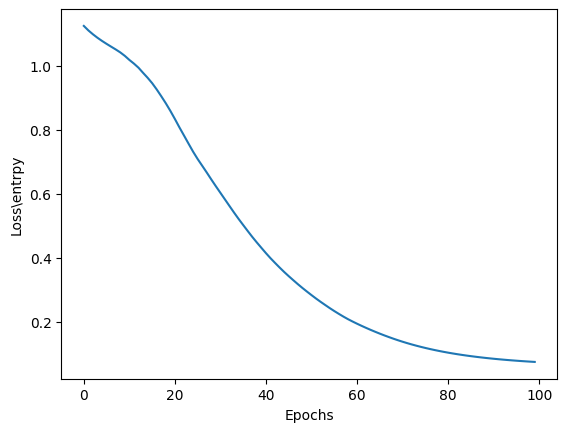

In [54]:
import matplotlib.pyplot as plt
plt.plot(range(epochs),losses)
plt.xlabel("Epochs")
plt.ylabel("Loss\entrpy")